**Manažerské shrnutí**

- doplnit texty

**Příprava prostředí**

In [1]:
import subprocess
import re


# Kontrola verze JDK. Balíček r5py vyžaduje novější verzi JAVA, proto může být nutný update.
def ensure_jdk(min_major=21):
    """
    Zkontroluje, jestli je nainstalovaná Java ≥ min_major.
    Pokud ne, stáhne a nainstaluje Temurin JDK min_major.
    """
    # 1) Verze (stávající) Javy
    try:
        out = subprocess.check_output(['java', '-version'], stderr=subprocess.STDOUT)
        txt = out.decode()
        m = re.search(r'version "(?P<ver>\d+)', txt)
        current = int(m.group('ver')) if m else 0
    except Exception:
        current = 0

    # 2) Porovnánís požadovanou verzí
    if current < min_major:
        print(f"Detekována Java {current}, potřebuji alespoň {min_major}. Instaluji JDK {min_major}…")
        cmds = [
            "apt-get update -qq",
            "apt-get install -y wget tar",
            f"wget -q https://github.com/adoptium/temurin{min_major}-binaries/releases/download/jdk-{min_major}+35/"
            f"OpenJDK{min_major}U-jdk_x64_linux_hotspot_{min_major}_35.tar.gz -O openjdk{min_major}.tar.gz",
            f"mkdir -p /usr/lib/jvm/java-{min_major}",
            f"tar -xzf openjdk{min_major}.tar.gz -C /usr/lib/jvm/java-{min_major} --strip-components=1",
            f"update-alternatives --install /usr/bin/java java /usr/lib/jvm/java-{min_major}/bin/java 1",
            f"update-alternatives --install /usr/bin/javac javac /usr/lib/jvm/java-{min_major}/bin/javac 1",
            f"update-alternatives --set java /usr/lib/jvm/java-{min_major}/bin/java",
            f"update-alternatives --set javac /usr/lib/jvm/java-{min_major}/bin/javac"
        ]
        for cmd in cmds:
            print(f">>> {cmd}")
            subprocess.run(cmd, shell=True, check=True)
        # ověření
        print(subprocess.check_output(['java', '-version'], stderr=subprocess.STDOUT).decode())
    else:
        print(f"Java je ve verzi {current}, což vyhovuje (≥ {min_major}).")

ensure_jdk(21)

Detekována Java 11, potřebuji alespoň 21. Instaluji JDK 21…
>>> apt-get update -qq
>>> apt-get install -y wget tar
>>> wget -q https://github.com/adoptium/temurin21-binaries/releases/download/jdk-21+35/OpenJDK21U-jdk_x64_linux_hotspot_21_35.tar.gz -O openjdk21.tar.gz
>>> mkdir -p /usr/lib/jvm/java-21
>>> tar -xzf openjdk21.tar.gz -C /usr/lib/jvm/java-21 --strip-components=1
>>> update-alternatives --install /usr/bin/java java /usr/lib/jvm/java-21/bin/java 1
>>> update-alternatives --install /usr/bin/javac javac /usr/lib/jvm/java-21/bin/javac 1
>>> update-alternatives --set java /usr/lib/jvm/java-21/bin/java
>>> update-alternatives --set javac /usr/lib/jvm/java-21/bin/javac
openjdk version "21" 2023-09-19 LTS
OpenJDK Runtime Environment Temurin-21+35 (build 21+35-LTS)
OpenJDK 64-Bit Server VM Temurin-21+35 (build 21+35-LTS, mixed mode, sharing)



In [2]:
# Kontrola požadovaných balíčků a jejich případná instalace pokud nejsou nalezeny
import importlib.util
import sys

packages = ['osmnx', 'r5py', 'geopandas', 'matplotlib', 'pandas', 'shapely',
            'folium', 'osm2geojson', 'mapclassify', "contextily", "nbconvert"]

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

for package in packages:
    if importlib.util.find_spec(package) is None:
        print(f"Balíček {package} nebyl nalezen. Instaluji...")
        install_package(package)
    else:
        print(f"Balíček {package} je již nainstalován.")

Balíček osmnx nebyl nalezen. Instaluji...
Balíček r5py nebyl nalezen. Instaluji...
Balíček geopandas je již nainstalován.
Balíček matplotlib je již nainstalován.
Balíček pandas je již nainstalován.
Balíček shapely je již nainstalován.
Balíček folium nebyl nalezen. Instaluji...
Balíček osm2geojson nebyl nalezen. Instaluji...
Balíček mapclassify nebyl nalezen. Instaluji...
Balíček contextily nebyl nalezen. Instaluji...
Balíček nbconvert je již nainstalován.


In [3]:
# import knihoven
import geopandas as gpd # práce s geospatial daty
import matplotlib.pyplot as plt # vizualizace
import osmnx as ox # práce s  Openstreetmap daty
import osm2geojson # práce s Openstreetmap daty
import pandas as pd # data manipulation a analýza
import r5py # routing engine - časy a trasy
from shapely.geometry import Polygon, shape, Point # práce s polygony
import folium # interaktivní mapy
import contextily as ctx # basemaps
import requests # interakce s webovými službami a API
import nbconvert # konverze Jupiter notebooku do html, pdf apod.
from google.colab import data_table
data_table.disable_dataframe_formatter()
# Možnost pracovat v R.
%load_ext rpy2.ipython

**Geografické vymezení úlohy**



Načtení hranic Jihomoravského kraje a jednotlivých okresů

*   Položka seznamu
*   Položka seznamu




In [4]:
# API pro ADM2 v ČR (okresy).
api_url_okr = "https://www.geoboundaries.org/api/current/gbOpen/CZE/ADM2"
hranice_okr = requests.get(api_url_okr)
len(hranice_okr.json())

# Všechny okresy ČR, kontrola názvů
okresy = gpd.read_file(hranice_okr.json()['gjDownloadURL'])
display(okresy.head())
print(okresy["shapeName"].unique())

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Nový Jičín,,57006924B81305487356227,CZE,ADM2,"POLYGON ((18.04966 49.80866, 18.04867 49.80073..."
1,Cheb,,57006924B74936445485800,CZE,ADM2,"POLYGON ((12.38127 50.28779, 12.37307 50.28735..."
2,Sokolov,,57006924B20358302460191,CZE,ADM2,"POLYGON ((12.82103 50.04788, 12.82059 50.05541..."
3,Karlovy Vary,,57006924B50757157558324,CZE,ADM2,"POLYGON ((12.9561 49.9789, 12.95588 49.98081, ..."
4,Chomutov,,57006924B32669310027153,CZE,ADM2,"POLYGON ((13.25622 50.23573, 13.25958 50.23615..."


['Nový Jičín' 'Cheb' 'Sokolov' 'Karlovy Vary' 'Chomutov' 'Most' 'Teplice'
 'Ústí nad Labem' 'Děčín' 'Louny' 'Litoměřice' 'Česká Lípa' 'Liberec'
 'Jablonec nad Nisou' 'Semily' 'Trutnov' 'Náchod' 'Tachov' 'Domažlice'
 'Plzeň-North' 'Rakovnik' 'Klatovy' 'Plzeň-South' 'Plzeň-City' 'Rokycany'
 'Kladno' 'Mělník' 'Mladá Boleslav' 'Jičín' 'Hradec Králové'
 'Rychnov nad Kněžnou' 'Pardubice' 'Chrudim' 'Ústí nad Orlicí' 'Jeseník'
 'Nymburk' 'Kolín' 'Beroun' 'Prague-East' 'Prague' 'Prague-West' 'Benešov'
 'Příbram' 'Kutná Hora' 'České Budějovice' 'Písek' 'Prachatice'
 'Strakonice' 'Český Krumlov' 'Jindřichův Hradec' 'Tábor' 'Třebíč'
 'Pelhřimov' 'Havlíčkův Brod' 'Žďár nad Sázavou' 'Jihlava' 'Vsetín'
 'Uherské Hradiště' 'Kroměříž' 'Zlín' 'Brno-Country' 'Svitavy' 'Hodonín'
 'Znojmo' 'Břeclav' 'Blansko' 'Vyškov' 'Brno-City' 'Prostějov' 'Přerov'
 'Olomouc' 'Bruntál' 'Šumperk' 'Opava' 'Karviná' 'Frýdek-Místek'
 'Ostrava-City']


In [5]:
jhm_okresy = ['Hodonín','Brno-Country','Znojmo', 'Břeclav', 'Blansko',
              'Vyškov', 'Brno-City']

jhm_okresy_gdf = okresy[okresy["shapeName"].isin(jhm_okresy)]
print(len(jhm_okresy_gdf)) # 7 okresů
print(jhm_okresy_gdf.crs)

7
EPSG:4326


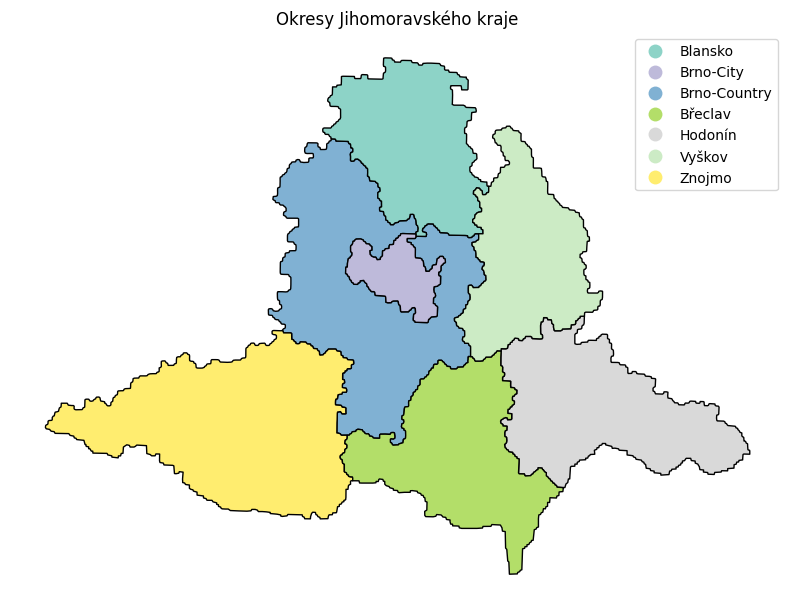

In [6]:
fig, ax = plt.subplots(figsize=(10,10))
jhm_okresy_gdf.plot(ax=ax, column="shapeName", cmap="Set3", legend=True, edgecolor='black')
ax.set_title("Okresy Jihomoravského kraje")
ax.set_axis_off()
plt.show()

In [7]:
# API pro ADM1 v ČR (kraj).
api_url_kraj = "https://www.geoboundaries.org/api/current/gbOpen/CZE/ADM1"
hranice_kraj = requests.get(api_url_kraj)
len(hranice_kraj.json())

# Všechny okresy ČR, kontrola názvů
kraje = gpd.read_file(hranice_kraj.json()['gjDownloadURL'])
display(kraje.head())
print(kraje["shapeName"].unique())

jmk = kraje[kraje["shapeName"] == "Jihomoravský kraj"]
print(jmk)

,shapeName,shapeISO,shapeID,shapeGroup,shapeType,geometry
0,Hlavní město Praha,CZ-10,73172107B16313596965023,CZE,ADM1,"POLYGON ((14.30231 50.12981, 14.30216 50.12958..."
1,Středočeský kraj,CZ-20,73172107B58641114734330,CZE,ADM1,"POLYGON ((15.4971 49.86111, 15.4971 49.86117, ..."
2,Jihočeský kraj,CZ-31,73172107B46425968394697,CZE,ADM1,"POLYGON ((13.76572 49.51394, 13.76493 49.51405..."
3,Plzeňský kraj,CZ-32,73172107B93878397098511,CZE,ADM1,"POLYGON ((13.40676 50.08958, 13.40637 50.08974..."
4,Karlovarský kraj,CZ-41,73172107B80386947470046,CZE,ADM1,"POLYGON ((13.30175 50.09935, 13.30129 50.09994..."


['Hlavní město Praha' 'Středočeský kraj' 'Jihočeský kraj' 'Plzeňský kraj'
 'Karlovarský kraj' 'Ústecký kraj' 'Liberecký kraj' 'Královéhradecký kraj'
 'Pardubický kraj' 'Kraj Vysočina' 'Jihomoravský kraj' 'Olomoucký kraj'
 'Moravskoslezský kraj' 'Zlínský kraj']
            shapeName shapeISO                  shapeID shapeGroup shapeType  \
10  Jihomoravský kraj    CZ-64  73172107B81289681513643        CZE      ADM1   

                                             geometry  
10  POLYGON ((15.54243 48.90774, 15.54349 48.90751...  


In [8]:
!pip install gdown
import gdown
file_id = "131v21t4yieXWoKU6deeRFB1N1PJKgXh6"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "zsj.zip", quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=131v21t4yieXWoKU6deeRFB1N1PJKgXh6
From (redirected): https://drive.google.com/uc?id=131v21t4yieXWoKU6deeRFB1N1PJKgXh6&confirm=t&uuid=1071f83f-43f9-49d9-a749-34e567299944
To: /content/zsj.zip
100%|██████████| 61.6M/61.6M [00:00<00:00, 80.5MB/s]


'zsj.zip'

In [9]:
!unzip zsj.zip -d "/content/Data_DAMI"

OpenJDK VM warning: the use of signal() and sigset() for signal chaining was deprecated in version 16.0 and will be removed in a future release. Use sigaction() instead.
Archive:  zsj.zip
  inflating: /content/Data_DAMI/SPH_ZSJ.cpg  
  inflating: /content/Data_DAMI/SPH_ZSJ.shx  
  inflating: /content/Data_DAMI/SPH_ZSJ.dbf  
  inflating: /content/Data_DAMI/SPH_ZSJ.shp  


In [10]:
# --- Příprava pro počáteční body ----

# 1) Načtení ZSJ shapefile - uložen na vašem Google Disku v /content/Data_DAMI
gdf_zsj = gpd.read_file('/content/Data_DAMI/SPH_ZSJ.shp')
gdf_zsj.head()
if gdf_zsj.crs is None:
  gdf_zsj.crs = 'epsg:5514'

gdf_zsj.to_crs(epsg=4326, inplace=True)

gdf_zsj_jmk = gdf_zsj[gdf_zsj.geometry.intersects(jmk.unary_union)]

gdf_zsj_jmk = gpd.clip(gdf_zsj, jmk)
print(len(gdf_zsj_jmk))
gdf_zsj_jmk.head()

<ipython-input-10-f6c0b9fea614>:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  gdf_zsj_jmk = gdf_zsj[gdf_zsj.geometry.intersects(jmk.unary_union)]


1746


,ID,KOD_ZSJ,GEO,KOD_LAU2,KOD_KATUZE,geometry
1988,13722.0,13722,Pohansko,584291.0,613584.0,"POLYGON ((16.93728 48.68435, 16.93761 48.68401..."
17668,176672.0,176672,Boří dvůr,584975.0,776696.0,"POLYGON ((16.779 48.7128, 16.77899 48.71279, 1..."
20134,304107.0,304107,Boří les,584291.0,726346.0,"POLYGON ((16.81299 48.71096, 16.81344 48.71195..."
12213,126365.0,126365,Štěpnice,584291.0,726346.0,"POLYGON ((16.8745 48.75134, 16.8757 48.7522, 1..."
17468,176699.0,176699,Valtice,584975.0,776696.0,"POLYGON ((16.77567 48.76528, 16.7757 48.76524,..."


Filtr Brno-střed, počet záznamů: 1
       kod       nazev             datum_exportu  ObjectId   Shape__Area  \
15  550973  Brno-střed 2024-09-14 00:00:00+00:00        16  3.425288e+07   

    Shape__Length                                           geometry  
15   32238.997112  POLYGON ((16.59367 49.21105, 16.59369 49.21099...  


<ipython-input-11-775b055406ae>:24: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
<ipython-input-11-775b055406ae>:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


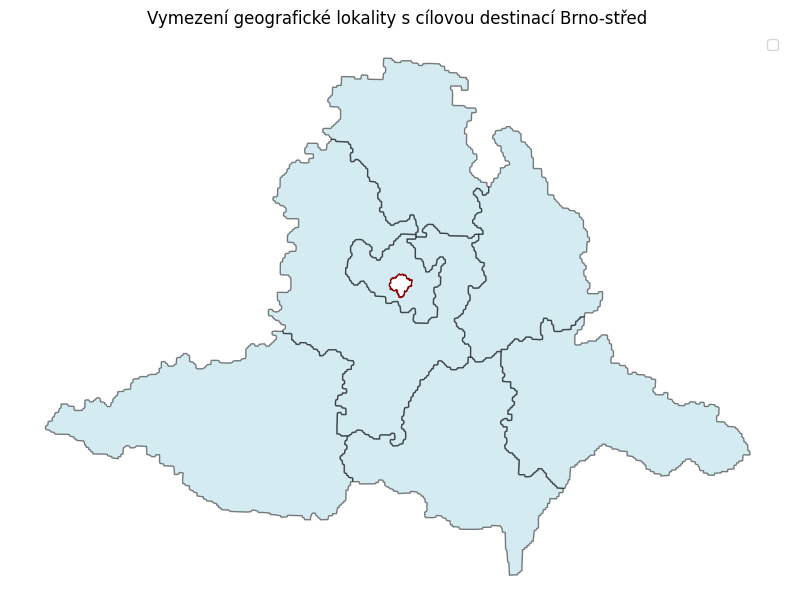

In [11]:
mestske_casti = gpd.read_file(
    "https://raw.githubusercontent.com/JanPelisek/dostupnost-JMK/main/Data_sources/m_casti_brno.geojson"
    )

# 3) Filtrace pro Brno-střed
brno_stred = mestske_casti[mestske_casti["nazev"] == "Brno-střed"]

print("Filtr Brno-střed, počet záznamů:", len(brno_stred))
print(brno_stred.head())

# 4) Kontrola a případná transformace do stejného CRS jako 'jhm_okresy_gdf'
#    Pokud jhm_okresy_gdf má jiný CRS, např. EPSG:5514 a brno_stred EPSG:4326, je třeba sjednotit.
if brno_stred.crs != jhm_okresy_gdf.crs:
    brno_stred = brno_stred.to_crs(jhm_okresy_gdf.crs)

# 5) Vykreslení - okresy a do nich polygon Brno-střed
fig, ax = plt.subplots(figsize=(10, 8))
jhm_okresy_gdf.plot(ax=ax, color="lightblue", edgecolor="black", alpha=0.5,
                    label="Okresy Jihomoravského kraje")
brno_stred.plot(ax=ax, color="white", edgecolor="darkred",
                alpha=1, label="Brno-střed")
ax.set_title("Vymezení geografické lokality s cílovou destinací Brno-střed")
ax.set_axis_off()
plt.legend()
plt.show()

CRS zastávek MHD: EPSG:4326
CRS Jihomoravského kraje: EPSG:4326


<ipython-input-12-a083e349dc2f>:57: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


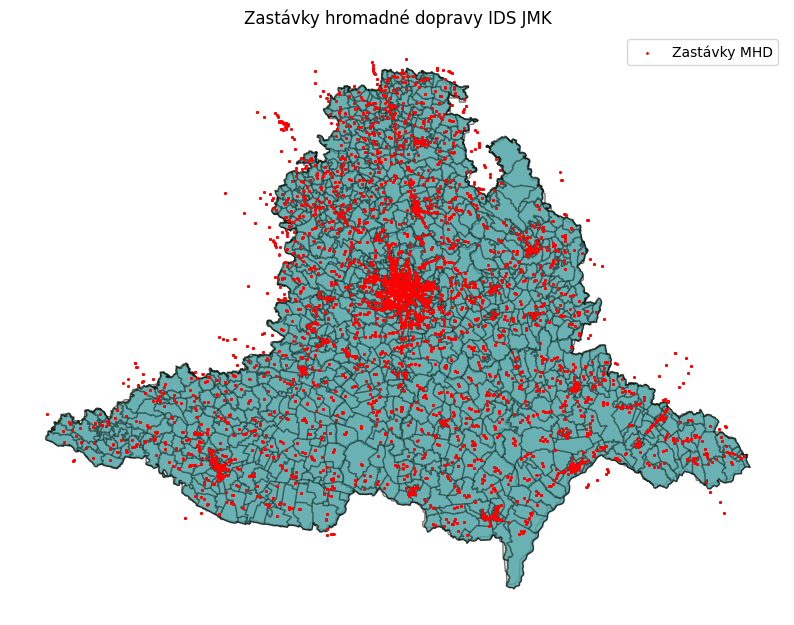

In [12]:
# Načtení zastávek
zastavky_mhd = gpd.read_file(
    "https://raw.githubusercontent.com/JanPelisek/dostupnost-JMK/main/Data_sources/stops_3349896397534691836.geojson"
    )

# Kontrolní výpis CRS systému
print("CRS zastávek MHD:", zastavky_mhd.crs)
print("CRS Jihomoravského kraje:", jhm_okresy_gdf.crs)

# Graf
fig, ax = plt.subplots(figsize=(10, 8))

# Okresy
jhm_okresy_gdf.plot(
    ax=ax,
    color="lightgrey",
    edgecolor="k",
    alpha=0.5,
    label="Okresy Jihomoravského kraje"
)

# Hranice JMK
jmk.plot(
    ax=ax,
    edgecolor="black",
    alpha=0.7,
    label="Jihomoravský kraj"
)

gdf_zsj_jmk.plot(
    ax=ax,
    color="lightgreen",
    edgecolor = "black",
    alpha=0.3,
    label="ZSJ"
)
# Brno-střed
brno_stred.plot(
    ax=ax,
    color="white",
    edgecolor="darkred",
    alpha=0.7,
    label="Brno-střed"
)

# Zastávky MHD
zastavky_mhd.plot(
    ax=ax,
    marker="o",
    color="red",
    markersize=1,
    label="Zastávky MHD"
)

ax.set_title("Zastávky hromadné dopravy IDS JMK")
ax.set_axis_off()
plt.legend()
plt.show()

In [13]:
# --- FILTRACE ZASTÁVEK UVNITŘ JMK ---

# 1) Jsou CRS zastávek i polygonu kraje jsou stejné?
zastavky_mhd = zastavky_mhd.to_crs(jmk.crs)

# 2) Sjednotíme polygon JMK do jednoho MultiPolygonu
jmk_union = jmk.unary_union

# 3) Zastávky uvnitř kraje
zastavky_jmk = zastavky_mhd[zastavky_mhd.geometry.within(jmk_union)]

# 4) Zastávky mimo kraj
zastavky_mimo_jmk = zastavky_mhd[~zastavky_mhd.index.isin(zastavky_jmk.index)]

# 5) Rychlý přehled
print(f"Zastávek celkem: {len(zastavky_mhd)}")
print(f"– v kraji: {len(zastavky_jmk)}")
print(f"– mimo kraj: {len(zastavky_mimo_jmk)}")

# 6) Tabulka zastávek mimo JMK
zastavky_mimo_jmk.head()

<ipython-input-13-2a5ddcc9bd6c>:7: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  jmk_union = jmk.unary_union


Zastávek celkem: 10817
– v kraji: 10164
– mimo kraj: 653


,stop_id,stop_name,latitude,longitude,zone_id,location_type,parent_station,wheelchair_boarding,platform_code,ObjectId,GlobalID,geometry
265,U15829Z1,"Laa an der Thaya, Stadtplatz",48.720393,16.384622,580.0,0,U15829N35,2\,NaN,266,d8522f2c-876e-4a6e-ae88-30e3643be2e8,POINT (16.38462 48.72039)
268,U15838Z1,"Laa an der Thaya, Bahnhof",48.722881,16.402679,580.0,0,U15838N36,2\,NaN,269,c6bd5ac8-7897-453c-b2a8-c8583de9dc18,POINT (16.40268 48.72288)
271,U15839Z1,"Laa an der Thaya, Therme",48.723047,16.395582,580.0,0,U15839N37,2\,NaN,272,ac2b0632-bab9-44c6-9d4e-234f6d425a3d,POINT (16.39558 48.72305)
274,U15839Z2,"Laa an der Thaya, Therme",48.723047,16.395582,580.0,0,U15839N37,2\,NaN,275,f9765e02-a164-4d2a-840c-5730b972969b,POINT (16.39558 48.72305)
277,U15838Z2,"Laa an der Thaya, Bahnhof",48.723331,16.402208,580.0,0,U15838N36,2\,NaN,278,eb5eb35c-0b21-451f-a81d-098968496be3,POINT (16.40221 48.72333)


In [14]:
# --- FILTRACE STARTOVACÍCH ZASTÁVEK MIMO OKRES BRNO-MĚSTO ---

# 1)
# Vybereme polygon okresu Brno‑město
brno_mesto_poly = (
    jhm_okresy_gdf
    .loc[jhm_okresy_gdf['shapeName'] == 'Brno-City', 'geometry']
    .unary_union
)

# 2) Filtr: zastávky v JMK, které nejsou uvnitř Brno‑město
start_zastavky = zastavky_jmk[~zastavky_jmk.geometry.intersects(brno_mesto_poly)]

# 3) Kontrola výsledku
print(f"Celkem zastávek v JMK: {len(zastavky_jmk)}")
print(f"Startovacích zastávek mimo Brno‑město: {len(start_zastavky)}")

# 4) Náhled
start_zastavky.head()


Celkem zastávek v JMK: 10164
Startovacích zastávek mimo Brno‑město: 8232


<ipython-input-14-dd03b257ec60>:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  .unary_union


,stop_id,stop_name,latitude,longitude,zone_id,location_type,parent_station,wheelchair_boarding,platform_code,ObjectId,GlobalID,geometry
2,U19012Z1,"Hodonín, STS",48.870733,17.116435,900.0,0,U19012N147,2\,NaN,3,8e763c9c-41a7-406b-b129-1f9ce1bbf764,POINT (17.11644 48.87073)
5,U19002Z1,"Hodonín, Brněnská",48.862476,17.118758,900.0,0,U19002N146,2\,NaN,6,c3a4f5c0-26d6-4661-90e7-daa437f04cd5,POINT (17.11876 48.86248)
7,U15775Z2,"Hevlín, škola",48.751285,16.380187,570.0,0,U15775N4,2\,NaN,8,9fd43094-867d-487f-8b9a-21b37775b978,POINT (16.38019 48.75128)
9,U16348Z1,"Klobouky u Brna, samoobsluha",48.995079,16.867518,640.0,0,U16348N160,2\,NaN,10,809a9be4-3411-4a2f-9dda-085e2cebd7f0,POINT (16.86752 48.99508)
10,U15773Z2,"Hevlín, cihelna",48.761387,16.383460,570.0,0,U15773N5,2\,NaN,11,e6cabbf5-a676-4d14-afbd-8d0c7482d76d,POINT (16.38346 48.76139)


In [15]:
# Startovací polygony ZSJ
# Odmazání polygonu Brno-město
start_zsj = gdf_zsj_jmk[~gdf_zsj_jmk.geometry.within(brno_mesto_poly)]
start_zsj = start_zsj.rename(columns={'ID':'id'})
start_zsj['id'] = start_zsj['id'].astype(int)

print(len(start_zsj))
start_zsj.head()

1502


,id,KOD_ZSJ,GEO,KOD_LAU2,KOD_KATUZE,geometry
1988,13722,13722,Pohansko,584291.0,613584.0,"POLYGON ((16.93728 48.68435, 16.93761 48.68401..."
17668,176672,176672,Boří dvůr,584975.0,776696.0,"POLYGON ((16.779 48.7128, 16.77899 48.71279, 1..."
20134,304107,304107,Boří les,584291.0,726346.0,"POLYGON ((16.81299 48.71096, 16.81344 48.71195..."
12213,126365,126365,Štěpnice,584291.0,726346.0,"POLYGON ((16.8745 48.75134, 16.8757 48.7522, 1..."
17468,176699,176699,Valtice,584975.0,776696.0,"POLYGON ((16.77567 48.76528, 16.7757 48.76524,..."


<ipython-input-16-fad3d984b1d4>:48: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


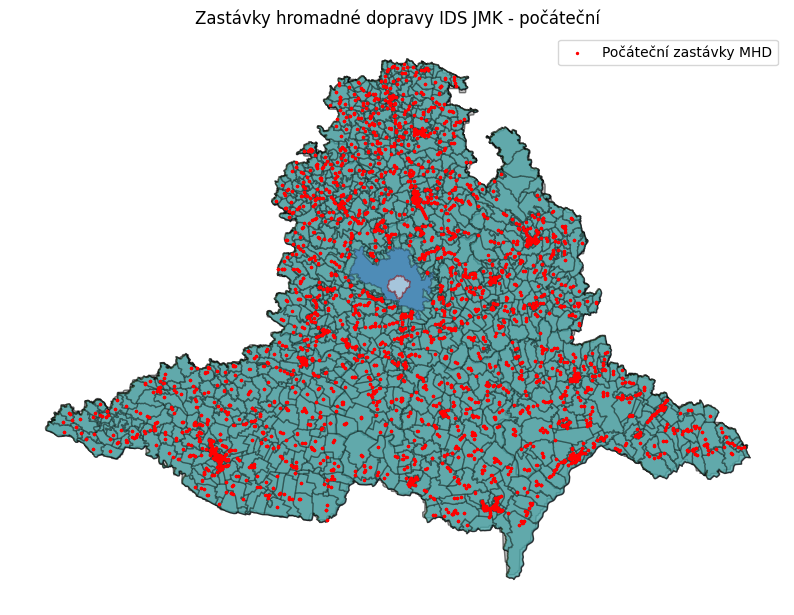

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))

# Okresy
jhm_okresy_gdf.plot(
    ax = ax,
    color = "grey",
    edgecolor = "black",
    alpha = 0.5,
    label = "Okresy Jihomoravského kraje"
)

# Hranice JMK
jmk.plot(
    ax = ax,
    edgecolor = "black",
    alpha = 0.7,
    label="Jihomoravský kraj"
)

# Brno-střed
brno_stred.plot(
    ax = ax,
    color = "white",
    edgecolor = "darkred",
    alpha = 0.5,
    label = "Brno-střed"
)

start_zsj.plot(
    ax=ax,
    color = "lightgreen",
    edgecolor = "black",
    alpha=0.3,
    label = "ZSJ"
)

# Počáteční zastávky MHD
start_zastavky.plot(
    ax = ax,
    marker = "o",
    color = "red",
    markersize = 2,
    label = "Počáteční zastávky MHD"
)

ax.set_title("Zastávky hromadné dopravy IDS JMK - počáteční")
ax.set_axis_off()
plt.legend()
plt.show()

In [17]:
# --- FILTRACE CÍLOVÝCH ZASTÁVEK V OKRUHU BRNO-STŘED ---
#
# polygon Brno-střed
target_area = brno_stred.unary_union

# Filtrace: zastávky, které leží uvnitř
target_zastavky = zastavky_jmk[zastavky_jmk.geometry.intersects(target_area)]

# Kontrola výsledků
print(f"Cílových zastávek v Brno-střed: {len(target_zastavky)}")
target_zastavky.head()

Cílových zastávek v Brno-střed: 342


<ipython-input-17-1858faf7a7e3>:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  target_area = brno_stred.unary_union


,stop_id,stop_name,latitude,longitude,zone_id,location_type,parent_station,wheelchair_boarding,platform_code,ObjectId,GlobalID,geometry
0,U7530Z2,Dolní nádraží,49.183292,16.615558,100.0,0,U7530N1,2\,NaN,1,3298db20-d9b0-49ac-9704-fc70e0918f17,POINT (16.61556 49.18329)
1,U1011Z2,Autobusové nádraží,49.186417,16.617622,100.0,0,U1011N2,2\,NaN,2,68f78079-ac24-41c9-9d03-912bb6bdcd1c,POINT (16.61762 49.18642)
3,U1146Z33,Hlavní nádraží,49.191850,16.613617,100.0,0,U1146N3,2\,13.0,4,514f47ce-9e97-4ac5-9b85-d3dbe56ad2d0,POINT (16.61362 49.19185)
4,U1146Z31,Hlavní nádraží,49.191815,16.613991,100.0,0,U1146N3,2\,10.0,5,d42fd377-8ff2-416d-8e7a-9380359f0b36,POINT (16.61399 49.19182)
6,U7530Z1,Dolní nádraží,49.183149,16.615201,100.0,0,U7530N1,2\,NaN,7,c3c24fc4-e19b-4c63-9277-177e54b67548,POINT (16.6152 49.18315)


<ipython-input-18-803964008265>:31: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


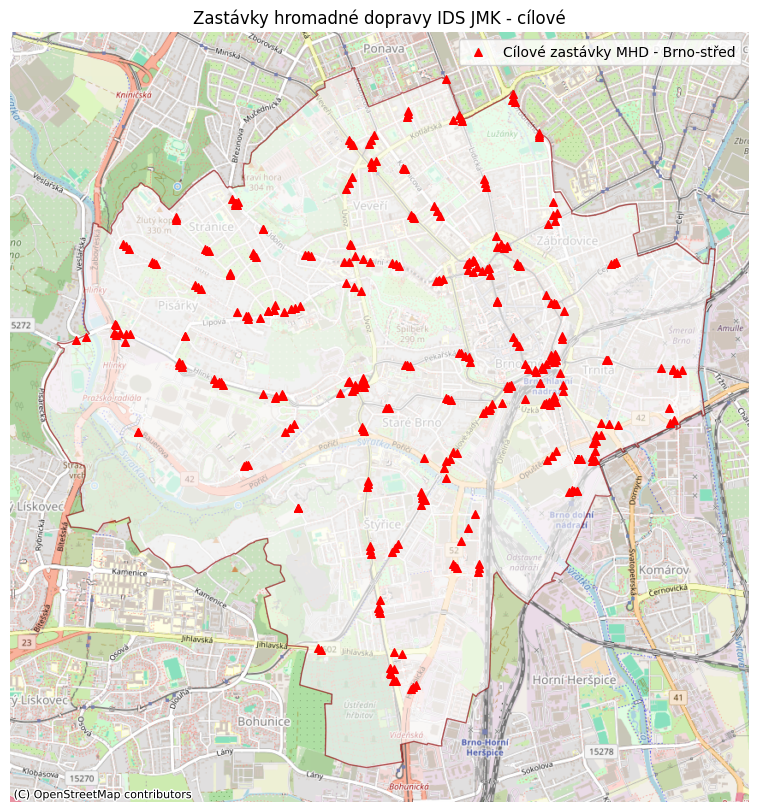

In [18]:
# Převod na Web Mercator
brno_wm = brno_stred.to_crs(epsg=3857)
target_wm = target_zastavky.to_crs(epsg=3857)

# Vykreslení
fig, ax = plt.subplots(figsize=(12, 10))
brno_wm.plot(
    ax=ax,
    color='white',
    edgecolor='darkred',
    alpha=0.6,
    label='Brno-střed'
)
target_wm.plot(
    ax=ax,
    marker='^',
    color='red',
    markersize=30,
    label='Cílové zastávky MHD - Brno-střed'
)

# Přidání basemap (např. OSM Mapnik)
ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    crs=target_wm.crs.to_string()
)

ax.set_title('Zastávky hromadné dopravy IDS JMK - cílové')
ax.set_axis_off()
ax.legend()
plt.show()

**Výpočet tras**

In [19]:
## stažení GTFS dat - soubor se uloží lokálně v /content na vašem disku Google
# GTFS pro 1. polovinu 2024. z učebních materiálů. S nejnovější verzí nefungovaly výpočty.
!wget -O improved-gtfs-ids-jmk.zip "https://raw.githubusercontent.com/JanPelisek/dostupnost-JMK/main/Data_sources/improved-gtfs-ids-jmk.zip"

OpenJDK VM warning: the use of signal() and sigset() for signal chaining was deprecated in version 16.0 and will be removed in a future release. Use sigaction() instead.
--2025-04-28 12:58:03--  https://raw.githubusercontent.com/JanPelisek/dostupnost-JMK/main/Data_sources/improved-gtfs-ids-jmk.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5732295 (5.5M) [application/zip]
Saving to: ‘improved-gtfs-ids-jmk.zip’

improved-gtfs-ids-j 100%[===================>]   5.47M  --.-KB/s    in 0.09s   

2025-04-28 12:58:04 (62.7 MB/s) - ‘improved-gtfs-ids-jmk.zip’ saved [5732295/5732295]



In [20]:
# stažení OSM.PBF - soubor se uloží lokálně v /content na vašem disku Google
# Nezbytné pro vytvoření dopvní sítě
!wget -O czech_republic.osm.pbf "https://download.geofabrik.de/europe/czech-republic-latest.osm.pbf"

OpenJDK VM warning: the use of signal() and sigset() for signal chaining was deprecated in version 16.0 and will be removed in a future release. Use sigaction() instead.
--2025-04-28 12:58:04--  https://download.geofabrik.de/europe/czech-republic-latest.osm.pbf
Resolving download.geofabrik.de (download.geofabrik.de)... 95.217.63.98, 65.21.229.87, 95.216.245.233, ...
Connecting to download.geofabrik.de (download.geofabrik.de)|95.217.63.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 886512789 (845M) [application/octet-stream]
Saving to: ‘czech_republic.osm.pbf’

czech_republic.osm. 100%[===================>] 845.44M  17.6MB/s    in 47s     

2025-04-28 12:58:52 (18.0 MB/s) - ‘czech_republic.osm.pbf’ saved [886512789/886512789]



In [21]:
# Příprava vstupních (point on surface ZSJ) pro výpočty cestovních časů
origins = start_zsj[["id", "geometry"]].copy()
origins['geometry'] = start_zsj.geometry.centroid
origins.head()


<ipython-input-21-01ce9bf3b147>:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  origins['geometry'] = start_zsj.geometry.centroid


,id,geometry
1988,13722,POINT (16.91243 48.71413)
17668,176672,POINT (16.7983 48.71951)
20134,304107,POINT (16.84669 48.72508)
12213,126365,POINT (16.88188 48.74291)
17468,176699,POINT (16.77442 48.7453)


In [22]:
# Stažení OSM shape files pro síť cest - poslouží proupřesnění počátečních bodů
file_id = "1LP5MmteyBboanhGU7oEObfdMtqpWx8ig"
url = f"https://drive.google.com/uc?id={file_id}"
gdown.download(url, "osm_roads.zip", quiet=False)
!unzip osm_roads.zip -d "/content/Data_DAMI"

Downloading...
From (original): https://drive.google.com/uc?id=1LP5MmteyBboanhGU7oEObfdMtqpWx8ig
From (redirected): https://drive.google.com/uc?id=1LP5MmteyBboanhGU7oEObfdMtqpWx8ig&confirm=t&uuid=ef00b164-b1da-490c-9122-0a0092c1b0ff
To: /content/osm_roads.zip
100%|██████████| 204M/204M [00:02<00:00, 94.4MB/s]


OpenJDK VM warning: the use of signal() and sigset() for signal chaining was deprecated in version 16.0 and will be removed in a future release. Use sigaction() instead.
Archive:  osm_roads.zip
 extracting: /content/Data_DAMI/gis_osm_roads_free_1.cpg  
  inflating: /content/Data_DAMI/gis_osm_roads_free_1.dbf  
  inflating: /content/Data_DAMI/gis_osm_roads_free_1.prj  
  inflating: /content/Data_DAMI/gis_osm_roads_free_1.shp  
  inflating: /content/Data_DAMI/gis_osm_roads_free_1.shx  


In [23]:
# Vytvoření Geopandas data framu - osm roads
gdf_roads = gpd.read_file('/content/Data_DAMI/gis_osm_roads_free_1.shp')
roads_union = gdf_roads.geometry.unary_union

<ipython-input-23-545d85977a72>:3: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  roads_union = gdf_roads.geometry.unary_union


In [24]:
# Funkce pro výpočet posunu původního bodu origins na nejbližší routovatelnou cetu
from shapely.ops import nearest_points

def snap_to_roads(pt):
    # nearest_points vrátí (pt, snap_pt)
    _, snap_pt = nearest_points(pt, roads_union)
    return snap_pt

In [25]:
# Namapování bodů na cesty, silnice apod.
origins["geometry"] = origins.geometry.map(snap_to_roads)

In [26]:
stred = [49.195061, 16.606836]

# základ folium mapy s podkladem
m = folium.Map(
    location=stred,
    zoom_start=10,
    tiles="OpenStreetMap",
    attr="OpenStreetMap"
)

# vrstvy administrativních hranic a vstupní / výstupní body
brno_stred.explore(
    m=m,
    color="red",
    edgecolor="darkred",
    alpha=0.5,
    name="Brno‑střed - cílová destinace"
)

origins.explore(
    m=m,
    marker_type='circle_marker',
    marker_kwds={'radius': 5, 'color': 'blue', 'fill': True, 'fillOpacity': 0.7},
    name='Start – ZSJ'
)

start_zastavky.explore(
    m=m,
    marker_type='circle_marker',
    marker_kwds={'radius': 3, 'color': 'green', 'fill': True, 'fillOpacity': 0.7},
    name='Start – MHD'
)

folium.LayerControl().add_to(m)

# Zobrazení mapy
m

Output hidden; open in https://colab.research.google.com to view.

In [27]:
# Příprava koncových bodů (Zastávky v Brno-střed)
destinations = target_zastavky.rename(columns={'stop_id':'id'})[['id','geometry']]

In [28]:
# Kontrola vstupnich a koncovych bodu
print(origins.crs, destinations.crs)
print(origins.head(), len(origins))
print(destinations.head(), len (destinations))


EPSG:4326 EPSG:4326
           id                   geometry
1988    13722  POINT (16.91329 48.71531)
17668  176672  POINT (16.79841 48.71936)
20134  304107  POINT (16.84624 48.72571)
12213  126365  POINT (16.88213 48.74265)
17468  176699  POINT (16.77444 48.74515) 1502
         id                   geometry
0   U7530Z2  POINT (16.61556 49.18329)
1   U1011Z2  POINT (16.61762 49.18642)
3  U1146Z33  POINT (16.61362 49.19185)
4  U1146Z31  POINT (16.61399 49.19182)
6   U7530Z1   POINT (16.6152 49.18315) 342


In [29]:
# Vytvoření <transport_network> s potvrzení nebo chybovou hláškou na konci
# může běžet až 2 hodiny
try:
    transport_network = r5py.TransportNetwork(
        "/content/czech_republic.osm.pbf",  # povinný objekt, pro výpočty při jízdě autem (transpot mode CAR)
        ["/content/improved-gtfs-ids-jmk.zip"], # volitelný, umožňuje trasy MHD
        allow_errors=False
    )
    print("TransportNetwork vytvořen úspěšně:", transport_network)
except Exception as e:
    print("Chyba při vytváření TransportNetwork:", e)

TransportNetwork vytvořen úspěšně: <r5py.r5.transport_network.TransportNetwork object at 0x7e2a675fc390>


In [30]:
import datetime
# testovací proměnná s jedním výchozím bodem <start>
# start =  gpd.GeoDataFrame(
#    {
#        "id": ["test_station"],
#        "geometry": [Point(16.621316, 49.309809)]
#   },
#    crs="EPSG:4326",
#)

# Výpočet dojezdových časů - MHD, přístup na zastávku WALK, odjezd 6:45 + 45 min
# Výsledné časy jsou mediánem všech možných routovatelných tras ze start do cíle v minutovém intervalu
# V pracovní den
# Výpočet je omezen na maximální cestovní čas 120 min.
travel_time_prac_den = r5py.TravelTimeMatrix(
    transport_network,
    origins = origins,
    destinations = destinations,
    departure = datetime.datetime(2024,5,15,6,45),
    departure_time_window = datetime.timedelta(seconds = 2700),
    transport_modes = [r5py.TransportMode.TRANSIT],
    access_modes = [r5py.TransportMode.WALK, r5py.TransportMode.BICYCLE],
    snap_to_network = True
)

In [31]:
print(f"Počet záznamů: {len(travel_time_prac_den)}")
display(travel_time_prac_den.head())
travel_time_prac_den.info()

Počet záznamů: 513684


,from_id,to_id,travel_time
0,13722,U7530Z2,NaN
1,13722,U1011Z2,NaN
2,13722,U1146Z33,NaN
3,13722,U1146Z31,NaN
4,13722,U7530Z1,NaN


<class 'r5py.r5.travel_time_matrix.TravelTimeMatrix'>
RangeIndex: 513684 entries, 0 to 513683
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   from_id      513684 non-null  int64  
 1   to_id        513684 non-null  object 
 2   travel_time  279521 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 11.8+ MB


In [32]:
cestovni_casy_prac_den = start_zsj.merge(travel_time_prac_den, left_on='id',
                                         right_on = "from_id")

cestovni_casy_prac_den["travel_time"].describe().round()

,travel_time
count,279521.0
mean,84.0
std,22.0
min,16.0
25%,66.0
50%,86.0
75%,103.0
max,119.0


In [33]:
cestovni_casy_prac_den = cestovni_casy_prac_den.merge(
    target_zastavky[['stop_id', 'stop_name']],
    left_on='to_id', right_on='stop_id', how='left')

In [34]:
# agregace časů podle počátečního bodu
median_cesta_prac_den = cestovni_casy_prac_den.copy().groupby("from_id").median("travel_time")
median_cesta_prac_den = median_cesta_prac_den.reset_index()
median_cesta_prac_den[["id", "KOD_ZSJ", "KOD_LAU2", "KOD_KATUZE"]] =\
median_cesta_prac_den[["id", "KOD_ZSJ", "KOD_LAU2", "KOD_KATUZE"]].astype(int)
display(median_cesta_prac_den.head())
print(f"Počet Non-Null záznamů mediánu cestovního času: {(median_cesta_prac_den['travel_time'].count())}")

,from_id,id,KOD_ZSJ,KOD_LAU2,KOD_KATUZE,travel_time
0,43,43,43,581291,600041,62.0
1,400,400,400,586030,600407,119.0
2,698,698,698,582794,600695,68.5
3,701,701,701,582808,600709,78.0
4,817,817,817,544833,600814,NaN


Počet Non-Null záznamů mediánu cestovního času: 906


In [35]:
# vytvoření geopandas dataframu pro další vizualizaci, analýzu
median_cesta_prac_den = gpd.GeoDataFrame(
    median_cesta_prac_den,
    geometry=cestovni_casy_prac_den.groupby("from_id")['geometry'].first().values
    )
median_cesta_prac_den["nazev"] = cestovni_casy_prac_den.groupby("from_id")['GEO'].first().values

data_table.disable_dataframe_formatter()
display(median_cesta_prac_den.head())

# kontrola počtu záznamů - chybějící znamenají, že nešlo routovat žádnout cestu
print(f"Počet záznamů: {len(median_cesta_prac_den)}")
print(f"Počet Non-Null záznamů mediánu cestovního času: {(median_cesta_prac_den['travel_time'].count())}")

,from_id,id,KOD_ZSJ,KOD_LAU2,KOD_KATUZE,travel_time,geometry,nazev
0,43,43,43,581291,600041,62.0,"POLYGON ((16.6568 49.30467, 16.65737 49.30433,...",Adamov-střed
1,400,400,400,586030,600407,119.0,"POLYGON ((16.98737 49.02234, 16.98736 49.02239...",Archlebov
2,698,698,698,582794,600695,68.5,"POLYGON ((16.66734 49.28499, 16.66737 49.28503...",Babice nad Svitavou
3,701,701,701,582808,600709,78.0,"POLYGON ((16.35721 49.18445, 16.35697 49.18428...",Babice u Rosic
4,817,817,817,544833,600814,NaN,"MULTIPOLYGON (((15.60421 48.95372, 15.60349 48...",Bačkovice


Počet záznamů: 1502
Počet Non-Null záznamů mediánu cestovního času: 906


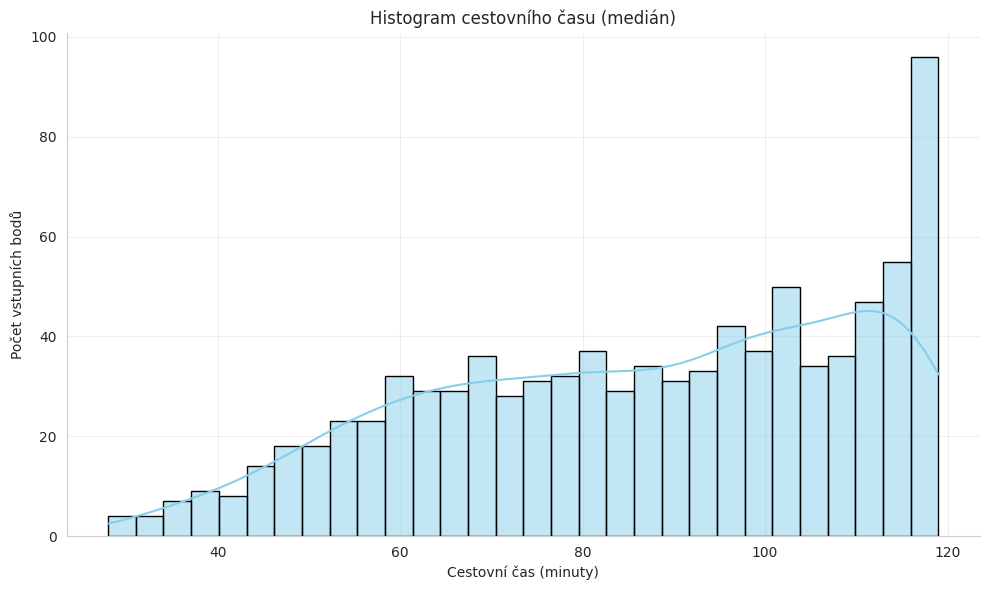

In [36]:
import seaborn as sns

# Set seaborn style
sns.set_style("whitegrid")

# Create the histogram
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(median_cesta_prac_den["travel_time"], bins=30, kde=True,
             color="skyblue", edgecolor="black", ax=ax)


ax.set_title("Histogram cestovního času (medián)")
ax.set_xlabel("Cestovní čas (minuty)")
ax.set_ylabel("Počet vstupních bodů")
ax.grid(True, alpha = 0.3)
sns.despine()

plt.tight_layout()
plt.show()

In [37]:
# --- Interaktivni vystup ---
from folium.plugins import MarkerCluster

# 1) střed mapy (např. průměrnou pozici vašich dat)
stred = [
    median_cesta_prac_den.geometry.centroid.y.mean(),
    median_cesta_prac_den.geometry.centroid.x.mean()
]

# základ folium mapy s podkladem
m = folium.Map(
    location=stred,
    zoom_start=11,
    tiles="OpenStreetMap",
    attr="OpenStreetMap"
)

# vrstvy administrativních hranic
brno_stred.explore(
    m=m,
    color="red",
    edgecolor="darkred",
    alpha=0.5,
    name="Brno‑střed - cílová destinace"
)

# choropleth mřížka cestovních časů
median_cesta_prac_den.explore(
    m=m,
    column="travel_time",
    cmap="BuPu",
    legend=True,
    name="Cestovní čas (medián)",
    tooltip=True     # umožní zobrazit hodnotu travel_time po najetí myší
)
# ovládání vrstev
folium.LayerControl(collapsed=False).add_to(m)

# Zobrazení mapy
m


Output hidden; open in https://colab.research.google.com to view.

In [38]:
lokality_df = pd.DataFrame({
    "id": median_cesta_prac_den["id"],
    "start": median_cesta_prac_den["nazev"],
    "median_casu_cesty": median_cesta_prac_den["travel_time"]
})


In [39]:
lokality_df.info()
lokality_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1502 entries, 0 to 1501
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1502 non-null   int64  
 1   start              1502 non-null   object 
 2   median_casu_cesty  906 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 35.3+ KB


,id,start,median_casu_cesty
0,43,Adamov-střed,62.0
1,400,Archlebov,119.0
2,698,Babice nad Svitavou,68.5
3,701,Babice u Rosic,78.0
4,817,Bačkovice,NaN


In [40]:
t_0 = 0
t_60 = 30
t_90 = 60
t_120 = 90
t_max = 120
bins = [t_0, t_60, t_90, t_120, t_max]

lokality_df['kategorie'] = pd.cut(
    lokality_df['median_casu_cesty'],
    bins = bins,
    labels = ["do 30 min.", "30 - 60 minut", "60 - 90 minut", "91 - 120 min."],
    include_lowest=True,
    duplicates='drop'
)
lokality_df.head()

,id,start,median_casu_cesty,kategorie
0,43,Adamov-střed,62.0,60 - 90 minut
1,400,Archlebov,119.0,91 - 120 min.
2,698,Babice nad Svitavou,68.5,60 - 90 minut
3,701,Babice u Rosic,78.0,60 - 90 minut
4,817,Bačkovice,NaN,NaN


In [41]:
total = median_cesta_prac_den["travel_time"].sum()

lokality_df["podil"] = (
    lokality_df
      .groupby("kategorie")["median_casu_cesty"]
      .transform("sum")
    / total
)
lokality_df["podil"] = lokality_df["podil"].round(2)
lokality_df.head()

<ipython-input-41-bb2fc7e18d54>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("kategorie")["median_casu_cesty"]


,id,start,median_casu_cesty,kategorie,podil
0,43,Adamov-střed,62.0,60 - 90 minut,0.3
1,400,Archlebov,119.0,91 - 120 min.,0.6
2,698,Babice nad Svitavou,68.5,60 - 90 minut,0.3
3,701,Babice u Rosic,78.0,60 - 90 minut,0.3
4,817,Bačkovice,NaN,NaN,NaN


<ipython-input-59-2ee707deea00>:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  shares = lokality_df.groupby('kategorie')['podil'].sum().sort_index()


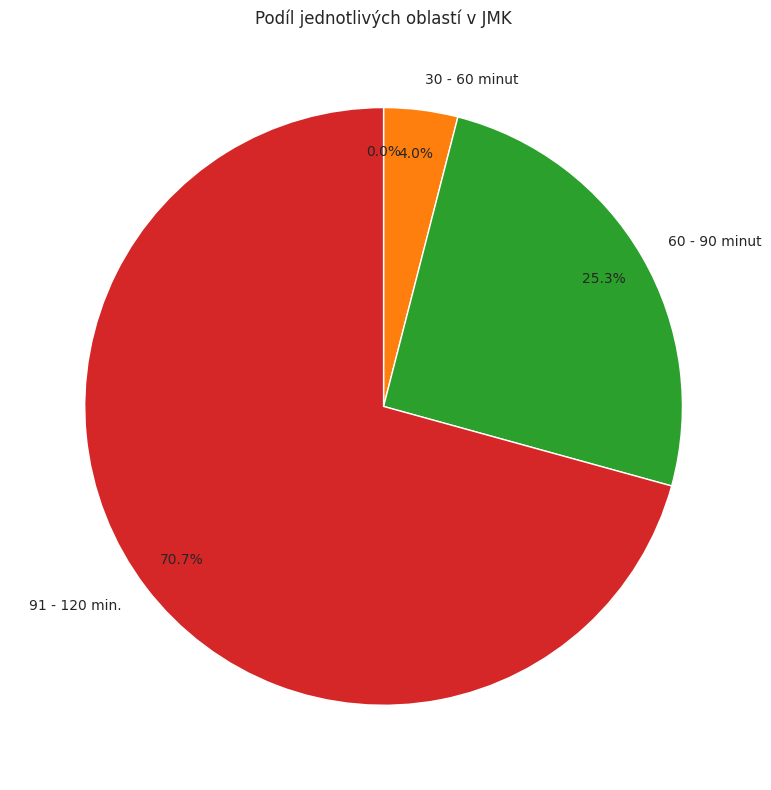

In [59]:
shares = lokality_df.groupby('kategorie')['podil'].sum().sort_index()

# 2) Vykreslete koláčový graf
fig, ax = plt.subplots(figsize=(8, 8))
shares.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    ax=ax,
    pctdistance = 0.85
)
ax.set_ylabel('')  # odstraní popisek osy y
ax.set_title('Podíl jednotlivých oblastí v JMK')
plt.tight_layout()
plt.show()

In [43]:
kategorie = (
    lokality_df
      .groupby('kategorie')
      .agg(
          minimum=('median_casu_cesty', 'min'),
          maximum=('median_casu_cesty', 'max'),
          prumer = ('median_casu_cesty', 'mean'),
          pocet   =('id', 'count'),
      )
)

kategorie["prumer"] = kategorie["prumer"].round(1)

display(kategorie)

<ipython-input-43-b8e4a7a7644a>:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('kategorie')


,minimum,maximum,prumer,pocet
kategorie,,,,
do 30 min.,28.0,30.0,29.0,4
30 - 60 minut,32.0,60.0,50.4,149
60 - 90 minut,61.0,90.0,76.0,314
91 - 120 min.,91.0,119.0,106.9,439


In [44]:
lokality_60 = lokality_df[lokality_df["median_casu_cesty"] <= 60]
lokality_60 = lokality_60.sort_values(by="median_casu_cesty")
lokality_60.info()
lokalita_75 = lokality_df[(lokality_df["median_casu_cesty"] > 60) & (lokality_df["median_casu_cesty"] <= 75)]
lokalita_75 = lokalita_75.sort_values(by="median_casu_cesty")
lokalita_75.info()
lokality_90 = lokality_df[(lokality_df["median_casu_cesty"] > 75) & (lokality_df["median_casu_cesty"] <= 90)]
lokality_90 = lokality_90.sort_values(by="median_casu_cesty")
lokality_90.info()

<class 'pandas.core.frame.DataFrame'>
Index: 153 entries, 1296 to 1374
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 153 non-null    int64   
 1   start              153 non-null    object  
 2   median_casu_cesty  153 non-null    float64 
 3   kategorie          153 non-null    category
 4   podil              153 non-null    float64 
dtypes: category(1), float64(2), int64(1), object(1)
memory usage: 6.3+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 1279 to 1477
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 149 non-null    int64   
 1   start              149 non-null    object  
 2   median_casu_cesty  149 non-null    float64 
 3   kategorie          149 non-null    category
 4   podil              149 non-null    float64 
dtypes: category(1), float64(2), 

In [45]:
data_table.enable_dataframe_formatter()
lokality_60

,id,start,median_casu_cesty,kategorie,podil
1296,304000,Sevastopolská,28.0,do 30 min.,0.0
107,12157,Vídeňská-jih,29.0,do 30 min.,0.0
113,12386,Líšeň-sever,29.0,do 30 min.,0.0
1495,331911,Ořechovská,30.0,do 30 min.,0.0
1055,168726,Troubsko-u zastávky,32.0,30 - 60 minut,0.1
...,...,...,...,...,...
31,5037,U kamenného kříže,60.0,30 - 60 minut,0.1
109,12203,Kněžské háje,60.0,30 - 60 minut,0.1
324,45705,Hostěrádky-Rešov,60.0,30 - 60 minut,0.1
862,141267,Obora,60.0,30 - 60 minut,0.1


In [46]:
lokalita_75

,id,start,median_casu_cesty,kategorie,podil
1279,196746,Stadion,61.0,60 - 90 minut,0.3
912,147818,Silůvky,61.0,60 - 90 minut,0.3
746,113182,Oslavany-střed,61.0,60 - 90 minut,0.3
1249,194123,Žabčice,61.0,60 - 90 minut,0.3
697,104761,Nížkovice,61.0,60 - 90 minut,0.3
...,...,...,...,...,...
801,133019,Pravlov,75.0,60 - 90 minut,0.3
933,151092,Smolín,75.0,60 - 90 minut,0.3
145,13668,Průmyslový obvod-východ,75.0,60 - 90 minut,0.3
36,5088,Sloupečník,75.0,60 - 90 minut,0.3


In [47]:
data_table.disable_dataframe_formatter

<function google.colab.data_table.disable_dataframe_formatter()>

In [48]:
gpd_lokality_60 = gpd.GeoDataFrame(
    lokality_60,
    geometry=median_cesta_prac_den.geometry
)

gpd_lokality_75 = gpd.GeoDataFrame(
    lokalita_75,
    geometry=median_cesta_prac_den.geometry
)

gdp_lokality_90 = gpd.GeoDataFrame(
    lokality_90,
    geometry=median_cesta_prac_den.geometry
)

# 1) střed mapy (např. průměrnou pozici vašich dat)
stred = [
    median_cesta_prac_den.geometry.centroid.y.mean(),
    median_cesta_prac_den.geometry.centroid.x.mean()
]

# 2) základ folium mapy s podkladem
m = folium.Map(
    location=stred,
    zoom_start=11,
    tiles="OpenStreetMap",
    attr="OpenStreetMap"
)

# 4) vrstvy administrativních hranic
brno_stred.explore(
    m=m,
    color="red",
    edgecolor="darkred",
    alpha=0.5,
    name="Brno‑střed - cílová destinace"
)

gpd_lokality_60.explore(
    m=m,
    color = "blue",
    alpha = 0.5,
    name='Lokalita s dostupností do 60 minut'
)

gpd_lokality_75.explore(
    m=m,
    color = "green",
    alpha = 0.5,
    name='Lokalita s dostupností od 61 do 75 minut'
)

gdp_lokality_90.explore(
    m=m,
    color = "orange",
    alpha = 0.5,
    name='Lokalita s dostupností od 76 do 90 minut'
)

# ovládání vrstev
folium.LayerControl(collapsed=False).add_to(m)

# Zobrazení mapy
m

Output hidden; open in https://colab.research.google.com to view.